# Zadanie 11.4

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

x_train = np.linspace(1, 10, 1000).reshape(-1, 1)
y_train = np.log(x_train**2)

print(f"Zakres x: {x_train.min()} - {x_train.max()}")
print(f"Zakres y: {y_train.min():.4f} - {y_train.max():.4f}")

Zakres x: 1.0 - 10.0
Zakres y: 0.0000 - 4.6052


In [24]:
model = Sequential([

    Dense(64, activation='relu', input_shape=(1,)), 
    Dense(32, activation='relu'),
    Dense(1)
])


model.compile(optimizer='adam', loss='mse')
history = model.fit(x_train, y_train, epochs=150, batch_size=32, verbose=0)

# Sprawdzenie końcowego błędu
final_loss = history.history['loss'][-1]
print(f"Osiągnięty błąd (MSE): {final_loss:.6f}")
if final_loss < 0.01:
    print("Warunek Error < 0.01 został spełniony!")
else:
    print("Warunek nie został spełniony. Zwiększ liczbę epok lub neuronów.")


Osiągnięty błąd (MSE): 0.000261
Warunek Error < 0.01 został spełniony!


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


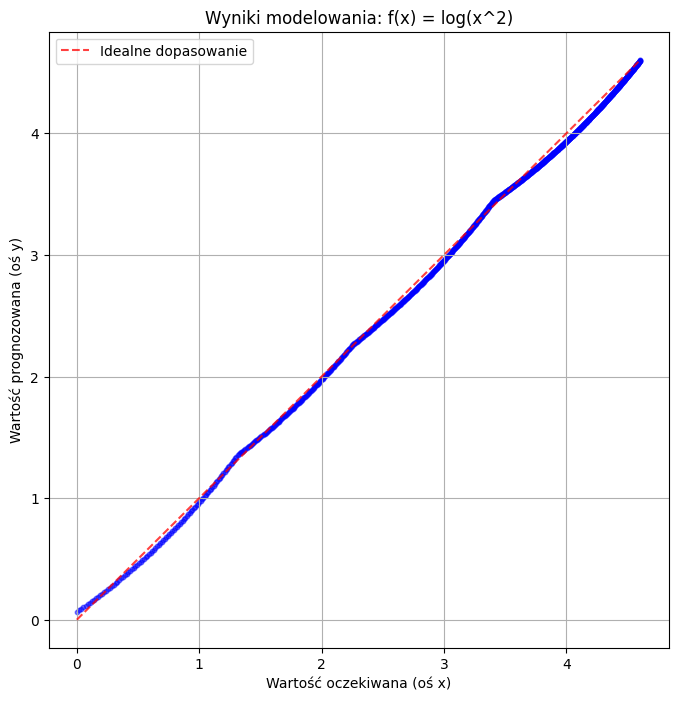

In [ ]:
y_pred = model.predict(x_train)

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred, alpha=0.5, color='blue', s=10)

lims = [np.min([y_train.min(), y_pred.min()]), np.max([y_train.max(), y_pred.max()])]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Idealne dopasowanie')

plt.title('Wyniki modelowania: f(x) = log(x^2)')
plt.xlabel('Wartość oczekiwana (oś x)')
plt.ylabel('Wartość prognozowana (oś y)')
plt.legend()
plt.grid(True)
plt.show()

# Zadanie 12.4

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
X = np.random.rand(1000, 4) * [200, 6, 100, 20] 

cena = X[:, 0] * 2000 + X[:, 1] * 5000 + np.random.normal(0, 1000, 1000)
koszty = X[:, 2] * 10 + X[:, 3] * 50 + np.random.normal(0, 50, 1000)
oplaty = X[:, 0] * 2 + np.random.normal(0, 5, 1000)

y = np.column_stack([cena, koszty, oplaty])

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),
    Dense(32, activation='relu'),
    Dense(3)
])

model.compile(optimizer='adam', loss='mse')

/home/main/Documents/School/NOD/NOD/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


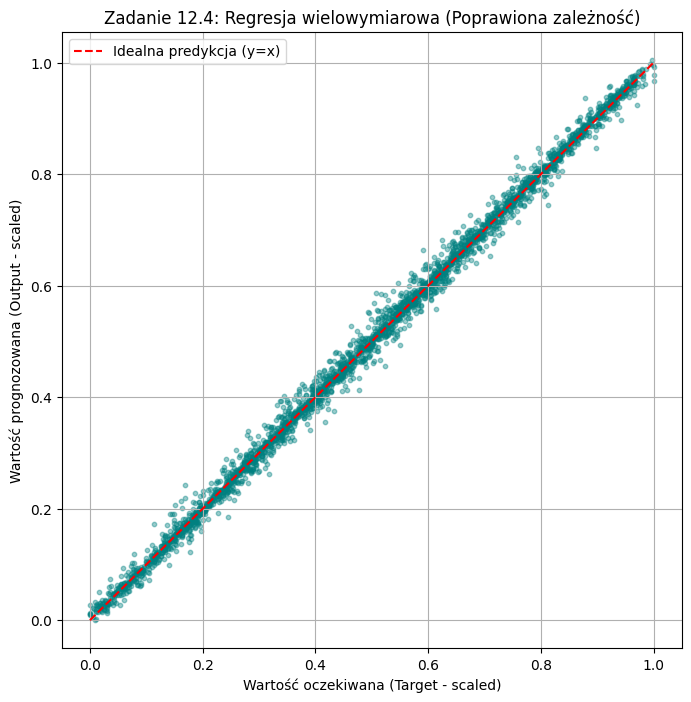

Końcowy błąd (MSE): 0.000256


In [27]:
history = model.fit(X_scaled, y_scaled, epochs=150, batch_size=32, verbose=0)

y_pred = model.predict(X_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_scaled, y_pred, alpha=0.4, color='teal', s=10)
plt.plot([0, 1], [0, 1], 'r--', label='Idealna predykcja (y=x)')

plt.title('Zadanie 12.4: Regresja wielowymiarowa (Poprawiona zależność)')
plt.xlabel('Wartość oczekiwana (Target - scaled)') # oś x 
plt.ylabel('Wartość prognozowana (Output - scaled)') # oś y 
plt.grid(True)
plt.legend()
plt.show()

print(f"Końcowy błąd (MSE): {history.history['loss'][-1]:.6f}")